In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [6]:

# PART 1: MATHEMATICAL CORE - KALMAN FILTER FOR PAIRS TRADING

class KalmanFilterPairsTrading:
    """
    Implements a Kalman Filter to dynamically estimate the hedge ratio
    between two cointegrated stocks for pairs trading.
    """
    
    def __init__(self, delta=1e-4, var_e=1e-3, var_eta=1e-3):
        """
        Initialize Kalman Filter parameters.
        
        Args:
            delta: Initial covariance (how uncertain we are initially)
            var_e: Observation noise variance
            var_eta: State transition noise variance
        """
        self.delta = delta
        self.var_e = var_e
        self.var_eta = var_eta
        
        # State variables
        self.wt = None  # State estimate (hedge ratio)
        self.Ct = None  # Covariance estimate
        self.At = None  # Prediction covariance
        self.Rt = None  # Innovation variance
        
    def initialize(self, y0, x0):
        """Initialize filter with first observation."""
        self.wt = y0 / x0 if x0 != 0 else 0
        self.Ct = self.delta
        
    def update(self, y, x):
        """
        Update the Kalman Filter with new observation.
        
        Args:
            y: Price of stock Y (dependent)
            x: Price of stock X (independent)
            
        Returns:
            et: Prediction error (spread)
            sqrt_Qt: Standard deviation of spread
        """
        if self.wt is None:
            self.initialize(y, x)
            return 0, np.sqrt(self.var_e)
        
        # Prediction step
        wt_minus = self.wt  # State prediction
        self.At = self.Ct + self.var_eta  # Prediction covariance
        
        # Update step
        et = y - wt_minus * x  # Innovation (prediction error)
        self.Rt = self.At * x**2 + self.var_e  # Innovation variance
        
        # Kalman gain
        Kt = self.At * x / self.Rt if self.Rt != 0 else 0
        
        # State update
        self.wt = wt_minus + Kt * et
        self.Ct = self.At - Kt * x * self.At
        
        # Spread standard deviation
        sqrt_Qt = np.sqrt(self.Rt)
        
        return et, sqrt_Qt
    
    def get_hedge_ratio(self):
        """Return current hedge ratio estimate."""
        return self.wt if self.wt is not None else 0


def calculate_z_score(spread, window=50):
    """
    Calculate z-score of the spread using rolling mean and std.
    
    Args:
        spread: Series of spread values
        window: Rolling window size
        
    Returns:
        z_score: Standardized spread
    """
    mean = spread.rolling(window=window).mean()
    std = spread.rolling(window=window).std()
    z_score = (spread - mean) / std
    return z_score


def generate_trading_signals(z_scores, entry_threshold=2.0, exit_threshold=0.5):
    """
    Generate trading signals based on z-score thresholds.
    
    Args:
        z_scores: Series of z-scores
        entry_threshold: Z-score threshold to enter position
        exit_threshold: Z-score threshold to exit position
        
    Returns:
        signals: 1 (long spread), -1 (short spread), 0 (no position)
    """
    signals = pd.Series(0, index=z_scores.index)
    position = 0
    
    for i in range(len(z_scores)):
        z = z_scores.iloc[i]
        
        if pd.isna(z):
            signals.iloc[i] = position
            continue
        
        # Entry signals
        if position == 0:
            if z > entry_threshold:
                position = -1  # Short spread (sell Y, buy X)
            elif z < -entry_threshold:
                position = 1   # Long spread (buy Y, sell X)
        
        # Exit signals
        elif position == 1 and z > -exit_threshold:
            position = 0
        elif position == -1 and z < exit_threshold:
            position = 0
        
        signals.iloc[i] = position
    
    return signals





    

In [7]:

# ============================================================================
# PART 2: MACHINE LEARNING - MARKET REGIME CLASSIFIER
# ============================================================================

class MarketRegimeClassifier:
    """
    ML model to classify market regimes as SAFE or UNSAFE for trading.
    Uses features like VIX, volatility, volume to detect crisis conditions.
    """
    
    def __init__(self):
        self.model = RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=20,
            random_state=42
        )
        self.scaler = StandardScaler()
        self.is_trained = False
        
    def create_features(self, prices, market_index, vix=None):
        """
        Create features for regime classification.
        
        Args:
            prices: DataFrame with stock prices
            market_index: Series of market index (e.g., SPY)
            vix: Optional VIX data
            
        Returns:
            features: DataFrame with engineered features
        """
        features = pd.DataFrame(index=prices.index)
        
        # Market volatility (realized)
        market_returns = market_index.pct_change()
        features['market_vol_20'] = market_returns.rolling(20).std() * np.sqrt(252)
        features['market_vol_5'] = market_returns.rolling(5).std() * np.sqrt(252)
        
        # Volume features (if available)
        if 'Volume' in prices.columns:
            features['volume_ratio'] = (
                prices['Volume'].rolling(5).mean() / 
                prices['Volume'].rolling(50).mean()
            )
        
        # Market stress indicators
        features['market_return_20'] = market_index.pct_change(20)
        features['max_drawdown_60'] = self._calculate_drawdown(market_index, 60)
        
        # VIX features (if available)
        if vix is not None:
            features['vix_level'] = vix
            features['vix_change'] = vix.pct_change(5)
        
        # Correlation breakdown (pairs divergence indicator)
        if len(prices.columns) >= 2:
            rolling_corr = prices.iloc[:, 0].rolling(30).corr(prices.iloc[:, 1])
            features['pair_correlation'] = rolling_corr
            features['corr_change'] = rolling_corr.diff(10)
        
        return features.ffill().fillna(0)
    
    def _calculate_drawdown(self, series, window):
        """Calculate maximum drawdown over rolling window."""
        rolling_max = series.rolling(window, min_periods=1).max()
        drawdown = (series - rolling_max) / rolling_max
        return drawdown
    
    def label_regimes(self, features, volatility_threshold=0.25, 
                     drawdown_threshold=-0.10):
        """
        Create labels for training: 0 = UNSAFE, 1 = SAFE.
        
        Args:
            features: Feature DataFrame
            volatility_threshold: Market vol above this = UNSAFE
            drawdown_threshold: Drawdown below this = UNSAFE
            
        Returns:
            labels: Series of regime labels
        """
        labels = pd.Series(1, index=features.index)  # Default: SAFE
        
        # Mark UNSAFE regimes
        if 'market_vol_20' in features.columns:
            labels[features['market_vol_20'] > volatility_threshold] = 0
        
        if 'max_drawdown_60' in features.columns:
            labels[features['max_drawdown_60'] < drawdown_threshold] = 0
        
        return labels
    
    def train(self, features, labels):
        """Train the regime classifier."""
        # Remove NaN rows
        valid_idx = ~(features.isna().any(axis=1) | labels.isna())
        X = features[valid_idx]
        y = labels[valid_idx]
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        
        # Train model
        self.model.fit(X_scaled, y)
        self.is_trained = True
        
        print(f"Regime classifier trained on {len(X)} samples")
        print(f"SAFE regimes: {(y==1).sum()}, UNSAFE regimes: {(y==0).sum()}")
        
    def predict(self, features):
        """
        Predict regime for new data.
        
        Returns:
            predictions: 1 = SAFE, 0 = UNSAFE
        """
        if not self.is_trained:
            raise ValueError("Model must be trained before prediction")
        
        X_scaled = self.scaler.transform(features.fillna(0))
        predictions = self.model.predict(X_scaled)
        return pd.Series(predictions, index=features.index)
    
    def get_feature_importance(self, feature_names):
        """Return feature importance from trained model."""
        if not self.is_trained:
            return None
        
        importance = pd.DataFrame({
            'feature': feature_names,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        return importance


In [8]:
# ============================================================================
# PART 3: INTEGRATED TRADING SYSTEM
# ============================================================================

class HybridPairsTradingSystem:
    """
    Complete hybrid system combining Kalman Filter pairs trading
    with ML-based regime filtering.
    """
    
    def __init__(self):
        self.kalman = KalmanFilterPairsTrading()
        self.regime_classifier = MarketRegimeClassifier()
        self.results = None
        
    def run_backtest(self, stock_y, stock_x, market_index, 
                     train_period=252, entry_z=2.0, exit_z=0.5):
        """
        Run complete backtest with both components.
        
        Args:
            stock_y: Price series for stock Y (dependent)
            stock_x: Price series for stock X (independent)
            market_index: Market index for regime detection
            train_period: Days to train regime classifier
            entry_z: Z-score threshold for entry
            exit_z: Z-score threshold for exit
            
        Returns:
            results: DataFrame with all signals and metrics
        """
        # Align all data
        data = pd.DataFrame({
            'Y': stock_y,
            'X': stock_x,
            'Market': market_index
        }).dropna()
        
        print(f"Backtest period: {data.index[0]} to {data.index[-1]}")
        print(f"Total trading days: {len(data)}")
        
        # Step 1: Run Kalman Filter to get spreads and z-scores
        spreads = []
        spread_stds = []
        hedge_ratios = []
        
        for i in range(len(data)):
            y = data['Y'].iloc[i]
            x = data['X'].iloc[i]
            
            et, sqrt_Qt = self.kalman.update(y, x)
            spreads.append(et)
            spread_stds.append(sqrt_Qt)
            hedge_ratios.append(self.kalman.get_hedge_ratio())
        
        data['spread'] = spreads
        data['spread_std'] = spread_stds
        data['hedge_ratio'] = hedge_ratios
        data['z_score'] = calculate_z_score(data['spread'], window=50)
        
        # Step 2: Generate math-based trading signals
        data['math_signal'] = generate_trading_signals(
            data['z_score'], 
            entry_threshold=entry_z, 
            exit_threshold=exit_z
        )
        
        # Step 3: Train regime classifier on training period
        prices_df = pd.DataFrame({'Y': stock_y, 'X': stock_x})
        features = self.regime_classifier.create_features(
            prices_df, 
            market_index
        )
        
        # Create training labels
        labels = self.regime_classifier.label_regimes(features)
        
        # Train on first train_period days
        train_features = features.iloc[:train_period]
        train_labels = labels.iloc[:train_period]
        
        self.regime_classifier.train(train_features, train_labels)
        
        # Step 4: Predict regimes for entire period
        data['regime'] = self.regime_classifier.predict(features)
        
        # Step 5: Combine signals (AND logic)
        data['final_signal'] = data['math_signal'] * data['regime']
        
        # Step 6: Calculate returns
        data['returns_Y'] = data['Y'].pct_change()
        data['returns_X'] = data['X'].pct_change()
        
        # Spread return = return of long Y minus hedge_ratio * return of short X
        data['spread_return'] = (
            data['returns_Y'] - data['hedge_ratio'] * data['returns_X']
        )
        
        # Strategy returns (with final signal)
        data['strategy_return'] = data['final_signal'].shift(1) * data['spread_return']
        
        # Math-only returns (no regime filter)
        data['math_only_return'] = data['math_signal'].shift(1) * data['spread_return']
        
        # Cumulative returns
        data['strategy_cumulative'] = (1 + data['strategy_return']).cumprod()
        data['math_only_cumulative'] = (1 + data['math_only_return']).cumprod()
        
        self.results = data
        return data
    
    def get_performance_metrics(self):
        """Calculate performance metrics for the strategy."""
        if self.results is None:
            raise ValueError("Must run backtest first")
        
        data = self.results
        
        # Strategy metrics
        strategy_returns = data['strategy_return'].dropna()
        math_only_returns = data['math_only_return'].dropna()
        
        metrics = {
            'Hybrid Strategy': self._calculate_metrics(strategy_returns),
            'Math Only': self._calculate_metrics(math_only_returns)
        }
        
        # Additional info
        total_days = len(data)
        safe_days = (data['regime'] == 1).sum()
        
        metrics['Additional Info'] = {
            'Total Trading Days': total_days,
            'Safe Regime Days': safe_days,
            'Unsafe Regime Days': total_days - safe_days,
            'Regime Filter Rate': f"{(1 - safe_days/total_days)*100:.1f}%"
        }
        
        return metrics
    
    def get_trade_analysis(self):
        """Get detailed trade-by-trade analysis."""
        if self.results is None:
            raise ValueError("Must run backtest first")
        
        data = self.results.copy()
        
        # Identify trade entries and exits
        data['position_change'] = data['final_signal'].diff()
        
        trades = []
        current_trade = None
        
        for i in range(len(data)):
            if data['position_change'].iloc[i] != 0 and data['final_signal'].iloc[i] != 0:
                # Entry
                if current_trade is None:
                    current_trade = {
                        'entry_date': data.index[i],
                        'entry_signal': data['final_signal'].iloc[i],
                        'entry_z': data['z_score'].iloc[i],
                        'entry_hedge': data['hedge_ratio'].iloc[i]
                    }
            
            elif data['position_change'].iloc[i] != 0 and data['final_signal'].iloc[i] == 0:
                # Exit
                if current_trade is not None:
                    exit_idx = i
                    entry_idx = data.index.get_loc(current_trade['entry_date'])
                    
                    trade_returns = data['strategy_return'].iloc[entry_idx:exit_idx+1]
                    trade_pnl = trade_returns.sum()
                    
                    current_trade.update({
                        'exit_date': data.index[i],
                        'exit_z': data['z_score'].iloc[i],
                        'duration_days': (data.index[i] - current_trade['entry_date']).days,
                        'pnl': trade_pnl,
                        'pnl_pct': trade_pnl * 100,
                        'profitable': trade_pnl > 0
                    })
                    
                    trades.append(current_trade)
                    current_trade = None
        
        return pd.DataFrame(trades)
    
    def get_monthly_returns(self):
        """Calculate monthly returns for heatmap visualization."""
        if self.results is None:
            raise ValueError("Must run backtest first")
        
        data = self.results.copy()
        
        # Calculate monthly returns for both strategies
        monthly_hybrid = data['strategy_return'].resample('M').sum() * 100
        monthly_math = data['math_only_return'].resample('M').sum() * 100
        
        # Create year-month pivot
        monthly_hybrid_pivot = monthly_hybrid.to_frame('return')
        monthly_hybrid_pivot['year'] = monthly_hybrid_pivot.index.year
        monthly_hybrid_pivot['month'] = monthly_hybrid_pivot.index.month
        
        monthly_math_pivot = monthly_math.to_frame('return')
        monthly_math_pivot['year'] = monthly_math_pivot.index.year
        monthly_math_pivot['month'] = monthly_math_pivot.index.month
        
        return {
            'hybrid': monthly_hybrid_pivot.pivot(index='year', columns='month', values='return'),
            'math_only': monthly_math_pivot.pivot(index='year', columns='month', values='return')
        }
    
    def _calculate_metrics(self, returns):
        """Calculate performance metrics for return series."""
        total_return = (1 + returns).prod() - 1
        annual_return = (1 + total_return) ** (252 / len(returns)) - 1
        annual_vol = returns.std() * np.sqrt(252)
        sharpe = annual_return / annual_vol if annual_vol != 0 else 0
        
        cumulative = (1 + returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        win_rate = (returns > 0).sum() / len(returns) if len(returns) > 0 else 0
        
        return {
            'Total Return': f"{total_return*100:.2f}%",
            'Annual Return': f"{annual_return*100:.2f}%",
            'Annual Volatility': f"{annual_vol*100:.2f}%",
            'Sharpe Ratio': f"{sharpe:.2f}",
            'Max Drawdown': f"{max_drawdown*100:.2f}%",
            'Win Rate': f"{win_rate*100:.1f}%",
            'Total Trades': len(returns[returns != 0])
        }


In [9]:

# ============================================================================
# PART 4: VISUALIZATION MODULES
# ============================================================================

class TradingVisualizer:
    """
    Comprehensive visualization module for the hybrid trading system.
    Creates publication-quality plots for analysis and presentation.
    """
    
    def __init__(self, results, stock_y_name='Stock Y', stock_x_name='Stock X'):
        self.results = results
        self.stock_y_name = stock_y_name
        self.stock_x_name = stock_x_name
        
    def plot_complete_analysis(self, figsize=(16, 12), save_path=None):
        """Create comprehensive analysis dashboard."""
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
        
        ax1 = fig.add_subplot(gs[0, :])
        self._plot_prices_with_regimes(ax1)
        
        ax2 = fig.add_subplot(gs[1, 0])
        self._plot_spread_and_zscore(ax2)
        
        ax3 = fig.add_subplot(gs[1, 1])
        self._plot_signals(ax3)
        
        ax4 = fig.add_subplot(gs[2, 0])
        self._plot_cumulative_returns(ax4)
        
        ax5 = fig.add_subplot(gs[2, 1])
        self._plot_drawdowns(ax5)
        
        plt.suptitle('Hybrid Pairs Trading System - Complete Analysis', 
                     fontsize=16, fontweight='bold', y=0.995)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.tight_layout()
        plt.show()
    
    def _plot_prices_with_regimes(self, ax):
        """Plot normalized prices with regime shading."""
        data = self.results
        y_norm = (data['Y'] / data['Y'].iloc[0]) * 100
        x_norm = (data['X'] / data['X'].iloc[0]) * 100
        
        ax.plot(data.index, y_norm, label=self.stock_y_name, 
                color='#2E86AB', linewidth=1.5, alpha=0.9)
        ax.plot(data.index, x_norm, label=self.stock_x_name, 
                color='#A23B72', linewidth=1.5, alpha=0.9)
        
        self._shade_regimes(ax, data)
        
        ax.set_ylabel('Normalized Price (Base=100)', fontweight='bold')
        ax.set_title('Stock Prices & Market Regimes', fontweight='bold', pad=10)
        ax.legend(loc='upper left', frameon=True, shadow=True)
        ax.grid(True, alpha=0.3)
        
    def _plot_spread_and_zscore(self, ax):
        """Plot z-score with entry/exit thresholds."""
        data = self.results.dropna(subset=['z_score'])
        
        ax.plot(data.index, data['z_score'], color='#264653', 
                linewidth=1, alpha=0.8, label='Z-Score')
        
        ax.axhline(y=2.0, color='#E76F51', linestyle='--', 
                   linewidth=1.5, label='Entry (±2σ)', alpha=0.7)
        ax.axhline(y=-2.0, color='#E76F51', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.axhline(y=0.5, color='#2A9D8F', linestyle=':', 
                   linewidth=1.5, label='Exit (±0.5σ)', alpha=0.7)
        ax.axhline(y=-0.5, color='#2A9D8F', linestyle=':', linewidth=1.5, alpha=0.7)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
        
        ax.fill_between(data.index, 2, 4, alpha=0.1, color='red')
        ax.fill_between(data.index, -2, -4, alpha=0.1, color='red')
        
        ax.set_ylabel('Z-Score', fontweight='bold')
        ax.set_title('Spread Z-Score', fontweight='bold', pad=10)
        ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([-4, 4])
        
    def _plot_signals(self, ax):
        """Plot trading signals comparison."""
        data = self.results
        
        ax.fill_between(data.index, 0, data['math_signal'], 
                        alpha=0.3, color='gray', label='Math Signal', step='post')
        ax.fill_between(data.index, 0, data['final_signal'], 
                        alpha=0.7, color='#2A9D8F', label='Final Signal', step='post')
        
        ax.axhline(y=0, color='black', linewidth=0.8)
        ax.set_ylabel('Position', fontweight='bold')
        ax.set_title('Trading Signals', fontweight='bold', pad=10)
        ax.set_ylim([-1.5, 1.5])
        ax.set_yticks([-1, 0, 1])
        ax.set_yticklabels(['Short', 'Flat', 'Long'])
        ax.legend(loc='upper right', frameon=True, shadow=True)
        ax.grid(True, alpha=0.3, axis='x')
        
    def _plot_cumulative_returns(self, ax):
        """Plot cumulative returns comparison."""
        data = self.results
        
        ax.plot(data.index, data['strategy_cumulative'], 
                label='Hybrid', color='#2A9D8F', linewidth=2, alpha=0.9)
        ax.plot(data.index, data['math_only_cumulative'], 
                label='Math Only', color='#E76F51', linewidth=2, alpha=0.7, linestyle='--')
        
        ax.axhline(y=1, color='black', linestyle=':', linewidth=1, alpha=0.5)
        
        ax.set_ylabel('Cumulative Return', fontweight='bold')
        ax.set_title('Performance Comparison', fontweight='bold', pad=10)
        ax.legend(loc='upper left', frameon=True, shadow=True)
        ax.grid(True, alpha=0.3)
        
        ax.yaxis.set_major_formatter(plt.FuncFormatter(
            lambda y, _: f'{(y-1)*100:,.0f}%'
        ))
        
    def _plot_drawdowns(self, ax):
        """Plot drawdown analysis."""
        data = self.results
        
        hybrid_cum = data['strategy_cumulative']
        math_cum = data['math_only_cumulative']
        
        hybrid_dd = self._calculate_drawdown_series(hybrid_cum)
        math_dd = self._calculate_drawdown_series(math_cum)
        
        ax.fill_between(data.index, 0, hybrid_dd * 100, 
                        alpha=0.7, color='#2A9D8F', label='Hybrid')
        ax.fill_between(data.index, 0, math_dd * 100, 
                        alpha=0.4, color='#E76F51', label='Math Only')
        
        ax.set_ylabel('Drawdown (%)', fontweight='bold')
        ax.set_title('Drawdown Analysis', fontweight='bold', pad=10)
        ax.legend(loc='lower right', frameon=True, shadow=True)
        ax.grid(True, alpha=0.3)
        
    def _shade_regimes(self, ax, data):
        """Add regime shading to plot."""
        unsafe = data[data['regime'] == 0]
        if len(unsafe) > 0:
            unsafe = unsafe.copy()
            unsafe['group'] = (unsafe.index.to_series().diff() > pd.Timedelta(days=2)).cumsum()
            
            for _, group in unsafe.groupby('group'):
                ax.axvspan(group.index[0], group.index[-1], alpha=0.15, color='red', zorder=0)
            
            ax.axvspan(data.index[0], data.index[0], 
                      alpha=0.15, color='red', label='Unsafe Regime')
    
    def _calculate_drawdown_series(self, cumulative_returns):
        """Calculate drawdown series."""
        running_max = cumulative_returns.expanding().max()
        return (cumulative_returns - running_max) / running_max
    
    def plot_regime_analysis(self, figsize=(14, 8), save_path=None):
        """Create detailed regime analysis plots."""
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Market Regime Analysis', fontsize=14, fontweight='bold')
        
        data = self.results
        
        # Volatility
        ax = axes[0, 0]
        vol = data['Market'].pct_change().rolling(20).std() * np.sqrt(252) * 100
        ax.plot(data.index, vol, color='#264653', linewidth=1.5)
        self._shade_regimes(ax, data)
        ax.axhline(y=25, color='red', linestyle='--', alpha=0.5)
        ax.set_ylabel('Volatility (%)', fontweight='bold')
        ax.set_title('Market Volatility')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Distribution
        ax = axes[0, 1]
        regime_counts = data['regime'].value_counts()
        ax.pie(regime_counts, labels=['UNSAFE', 'SAFE'], autopct='%1.1f%%',
               colors=['#E76F51', '#2A9D8F'], startangle=90)
        ax.set_title('Regime Distribution')
        
        # Returns by regime
        ax = axes[1, 0]
        safe_ret = data[data['regime'] == 1]['strategy_return'].dropna() * 100
        unsafe_ret = data[data['regime'] == 0]['math_signal'].shift(1) * data['spread_return'] * 100
        unsafe_ret = unsafe_ret[unsafe_ret != 0].dropna()
        
        bp = ax.boxplot([safe_ret, unsafe_ret], 
                       labels=['SAFE\n(Traded)', 'UNSAFE\n(Avoided)'],
                       patch_artist=True, widths=0.6)
        
        for patch, color in zip(bp['boxes'], ['#2A9D8F', '#E76F51']):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.set_ylabel('Return (%)', fontweight='bold')
        ax.set_title('Returns by Regime')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Signal filtering
        ax = axes[1, 1]
        total = (data['math_signal'] != 0).sum()
        executed = (data['final_signal'] != 0).sum()
        filtered = total - executed
        
        bars = ax.bar(['Math Signals', 'Filtered Out', 'Executed'], 
                     [total, filtered, executed],
                     color=['gray', '#E76F51', '#2A9D8F'], alpha=0.7)
        
        ax.set_ylabel('Number of Signals', fontweight='bold')
        ax.set_title('Signal Filtering Effect')
        ax.grid(True, alpha=0.3, axis='y')
        
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def create_interactive_dashboard(self):
        """Create interactive Plotly dashboard."""
        data = self.results
        
        # Create subplots
        fig = make_subplots(
            rows=3, cols=2,
            subplot_titles=('Price Movement', 'Z-Score',
                          'Trading Signals', 'Cumulative Returns',
                          'Drawdown', 'Monthly Returns'),
            vertical_spacing=0.1,
            horizontal_spacing=0.1,
            specs=[[{"secondary_y": False}, {"secondary_y": False}],
                   [{"secondary_y": False}, {"secondary_y": False}],
                   [{"secondary_y": False}, {"type": "heatmap"}]]
        )
        
        # 1. Prices
        fig.add_trace(
            go.Scatter(x=data.index, y=(data['Y']/data['Y'].iloc[0])*100,
                      name=self.stock_y_name, line=dict(color='#2E86AB', width=2)),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(x=data.index, y=(data['X']/data['X'].iloc[0])*100,
                      name=self.stock_x_name, line=dict(color='#A23B72', width=2)),
            row=1, col=1
        )
        
        # 2. Z-Score
        fig.add_trace(
            go.Scatter(x=data.index, y=data['z_score'],
                      name='Z-Score', line=dict(color='#264653', width=1.5)),
            row=1, col=2
        )
        fig.add_hline(y=2, line_dash="dash", line_color="red", row=1, col=2)
        fig.add_hline(y=-2, line_dash="dash", line_color="red", row=1, col=2)
        fig.add_hline(y=0.5, line_dash="dot", line_color="green", row=1, col=2)
        fig.add_hline(y=-0.5, line_dash="dot", line_color="green", row=1, col=2)
        
        # 3. Signals
        fig.add_trace(
            go.Scatter(x=data.index, y=data['math_signal'],
                      name='Math Signal', fill='tozeroy',
                      line=dict(color='gray', width=0), fillcolor='rgba(128,128,128,0.3)'),
            row=2, col=1
        )
        fig.add_trace(
            go.Scatter(x=data.index, y=data['final_signal'],
                      name='Final Signal', fill='tozeroy',
                      line=dict(color='#2A9D8F', width=0), fillcolor='rgba(42,157,143,0.7)'),
            row=2, col=1
        )
        
        # 4. Cumulative Returns
        fig.add_trace(
            go.Scatter(x=data.index, y=(data['strategy_cumulative']-1)*100,
                      name='Hybrid Strategy', line=dict(color='#2A9D8F', width=2)),
            row=2, col=2
        )
        fig.add_trace(
            go.Scatter(x=data.index, y=(data['math_only_cumulative']-1)*100,
                      name='Math Only', line=dict(color='#E76F51', width=2, dash='dash')),
            row=2, col=2
        )
        
        # 5. Drawdown
        hybrid_dd = self._calculate_drawdown_series(data['strategy_cumulative'])
        math_dd = self._calculate_drawdown_series(data['math_only_cumulative'])
        
        fig.add_trace(
            go.Scatter(x=data.index, y=hybrid_dd*100,
                      name='Hybrid DD', fill='tozeroy',
                      line=dict(color='#2A9D8F', width=0), fillcolor='rgba(42,157,143,0.5)'),
            row=3, col=1
        )
        fig.add_trace(
            go.Scatter(x=data.index, y=math_dd*100,
                      name='Math Only DD', fill='tozeroy',
                      line=dict(color='#E76F51', width=0), fillcolor='rgba(231,111,81,0.3)'),
            row=3, col=1
        )
        
        # Update layout
        fig.update_xaxes(title_text="Date", row=3, col=1)
        fig.update_xaxes(title_text="Date", row=3, col=2)
        fig.update_yaxes(title_text="Normalized Price", row=1, col=1)
        fig.update_yaxes(title_text="Z-Score", row=1, col=2)
        fig.update_yaxes(title_text="Position", row=2, col=1)
        fig.update_yaxes(title_text="Return (%)", row=2, col=2)
        fig.update_yaxes(title_text="Drawdown (%)", row=3, col=1)
        
        fig.update_layout(
            height=1000,
            showlegend=True,
            title_text="Interactive Trading Dashboard",
            title_font_size=20,
            hovermode='x unified'
        )
        
        return fig




In [10]:

# ============================================================================
# PART 5: MAIN EXECUTION & DEMO
# ============================================================================


def download_data(ticker_y, ticker_x, market_ticker='SPY', start_date='2018-01-01', end_date='2024-01-01'):
    """
    Download stock data from Yahoo Finance with improved error handling.
    
    Args:
        ticker_y: Ticker symbol for stock Y
        ticker_x: Ticker symbol for stock X
        market_ticker: Market index ticker (default: SPY)
        start_date: Start date for data
        end_date: End date for data
        
    Returns:
        Tuple of (stock_y, stock_x, market_index) price series
    """
    print(f"Downloading data for {ticker_y}, {ticker_x}, and {market_ticker}...")
    
    # Download data with auto_adjust=True to get adjusted prices directly
    data_y = yf.download(ticker_y, start=start_date, end=end_date, progress=False, auto_adjust=True)
    data_x = yf.download(ticker_x, start=start_date, end=end_date, progress=False, auto_adjust=True)
    data_market = yf.download(market_ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)
    
    # Extract Close prices (they're already adjusted when auto_adjust=True)
    def extract_close(df):
        """Extract close price handling both single and multi-ticker downloads"""
        if df.empty:
            raise ValueError("Downloaded data is empty")
        
        # If multi-level columns, get 'Close'
        if isinstance(df.columns, pd.MultiIndex):
            if 'Close' in df.columns.get_level_values(0):
                return df['Close'].iloc[:, 0].squeeze()
            else:
                # Fallback to first column
                return df.iloc[:, 0].squeeze()
        else:
            # Single level columns
            if 'Close' in df.columns:
                return df['Close'].squeeze()
            else:
                # If only one column, return it
                return df.iloc[:, 0].squeeze()
    
    stock_y = extract_close(data_y)
    stock_x = extract_close(data_x)
    market = extract_close(data_market)
    
    # Ensure they're Series
    if not isinstance(stock_y, pd.Series):
        stock_y = pd.Series(stock_y)
    if not isinstance(stock_x, pd.Series):
        stock_x = pd.Series(stock_x)
    if not isinstance(market, pd.Series):
        market = pd.Series(market)
    
    print(f"Downloaded {len(stock_y)} days of data")
    print(f"Date range: {stock_y.index[0]} to {stock_y.index[-1]}")
    
    return stock_y, stock_x, market

# Alternative: Manual data extraction if auto_adjust doesn't work
def download_data_alternative(ticker_y, ticker_x, market_ticker='SPY', start_date='2018-01-01', end_date='2024-01-01'):
    """
    Alternative download method with manual column selection.
    """
    print(f"Downloading data for {ticker_y}, {ticker_x}, and {market_ticker}...")
    
    # Download without auto_adjust
    data_y = yf.download(ticker_y, start=start_date, end=end_date, progress=False)
    data_x = yf.download(ticker_x, start=start_date, end=end_date, progress=False)
    data_market = yf.download(market_ticker, start=start_date, end=end_date, progress=False)
    
    # Debug: Print column structure
    print(f"Columns in data_y: {data_y.columns.tolist()}")
    
    # Try different column names
    possible_cols = ['Adj Close', 'Close', 'close', 'adj close']
    
    def get_price(df, ticker_name):
        """Flexibly extract price from DataFrame"""
        if df.empty:
            raise ValueError(f"No data downloaded for {ticker_name}")
        
        # MultiIndex case
        if isinstance(df.columns, pd.MultiIndex):
            for col in possible_cols:
                if col in df.columns.get_level_values(0):
                    return df[col].iloc[:, 0].squeeze()
            # If nothing found, return first column
            return df.iloc[:, 0].squeeze()
        
        # Single level case
        for col in possible_cols:
            if col in df.columns:
                return df[col].squeeze()
        
        # Last resort: return first numeric column
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            return df[numeric_cols[0]].squeeze()
        
        raise ValueError(f"Could not find price column in {ticker_name} data")
    
    stock_y = get_price(data_y, ticker_y)
    stock_x = get_price(data_x, ticker_x)
    market = get_price(data_market, market_ticker)
    
    print(f"Downloaded {len(stock_y)} days of data")
    print(f"Date range: {stock_y.index[0]} to {stock_y.index[-1]}")
    
    return stock_y, stock_x, market


# Test function to verify download works
def test_download():
    """Test the download function with a simple case"""
    try:
        print("Testing download with auto_adjust...")
        pep, ko, spy = download_data('PEP', 'KO', 'SPY', '2023-01-01', '2023-12-31')
        print(f"✓ Success! Got {len(pep)} data points")
        print(f"Sample PEP prices: {pep.head(3).tolist()}")
        return pep, ko, spy
    except Exception as e:
        print(f"✗ First method failed: {e}")
        print("\nTrying alternative method...")
        try:
            pep, ko, spy = download_data_alternative('PEP', 'KO', 'SPY', '2023-01-01', '2023-12-31')
            print(f"✓ Alternative success! Got {len(pep)} data points")
            return pep, ko, spy
        except Exception as e2:
            print(f"✗ Alternative also failed: {e2}")
            raise


# Usage instructions
print("""
USAGE INSTRUCTIONS:
==================

1. First, test if download works:
   test_download()

2. If successful, replace the download_data function in your main code with the fixed version above.

3. If first method fails, use download_data_alternative instead:
   # In your code, change:
   pep, ko, spy = download_data('PEP', 'KO', 'SPY', '2018-01-01', '2024-01-01')
   # To:
   pep, ko, spy = download_data_alternative('PEP', 'KO', 'SPY', '2018-01-01', '2024-01-01')

4. Run the test to see which method works for your yfinance version.
""")


def run_example_backtest():
    """
    Run a complete example backtest with popular stock pairs.
    This demonstrates the full system workflow.
    """
    print("="*80)
    print("HYBRID PAIRS TRADING SYSTEM - EXAMPLE BACKTEST")
    print("="*80)
    print()
    
    # Example 1: PEP vs KO (Pepsi vs Coca-Cola)
    print("Example: PEP (Pepsi) vs KO (Coca-Cola)")
    print("-" * 80)
    
    # Download data
    pep, ko, spy = download_data('PEP', 'KO', 'SPY', '2018-01-01', '2024-01-01')
    
    # Initialize system
    system = HybridPairsTradingSystem()
    
    # Run backtest
    print("\nRunning backtest...")
    results = system.run_backtest(
        stock_y=pep,
        stock_x=ko,
        market_index=spy,
        train_period=252,
        entry_z=2.0,
        exit_z=0.5
    )
    
    # Display performance metrics
    print("\n" + "="*80)
    print("PERFORMANCE METRICS")
    print("="*80)
    
    metrics = system.get_performance_metrics()
    
    for strategy_name, strategy_metrics in metrics.items():
        if strategy_name != 'Additional Info':
            print(f"\n{strategy_name}:")
            print("-" * 40)
            for metric, value in strategy_metrics.items():
                print(f"  {metric:.<30} {value}")
    
    print(f"\n{'Additional Information':}")
    print("-" * 40)
    for key, value in metrics['Additional Info'].items():
        print(f"  {key:.<30} {value}")
    
    # Trade analysis
    print("\n" + "="*80)
    print("TRADE ANALYSIS")
    print("="*80)
    
    trades = system.get_trade_analysis()
    if len(trades) > 0:
        print(f"\nTotal Trades: {len(trades)}")
        print(f"Winning Trades: {trades['profitable'].sum()}")
        print(f"Losing Trades: {(~trades['profitable']).sum()}")
        print(f"Win Rate: {trades['profitable'].mean()*100:.1f}%")
        print(f"\nAverage Trade Duration: {trades['duration_days'].mean():.1f} days")
        print(f"Average Winning Trade: {trades[trades['profitable']]['pnl_pct'].mean():.2f}%")
        print(f"Average Losing Trade: {trades[~trades['profitable']]['pnl_pct'].mean():.2f}%")
        
        print("\nLast 10 Trades:")
        print(trades[['entry_date', 'exit_date', 'duration_days', 'pnl_pct', 'profitable']].tail(10).to_string())
    else:
        print("No complete trades found in backtest period")
    
    # Visualizations
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    
    visualizer = TradingVisualizer(results, stock_y_name='PEP', stock_x_name='KO')
    
    # Static plots
    print("\nCreating comprehensive analysis plot...")
    visualizer.plot_complete_analysis(figsize=(16, 12))
    
    print("\nCreating regime analysis plot...")
    visualizer.plot_regime_analysis(figsize=(14, 8))
    
    # Interactive dashboard
    print("\nCreating interactive dashboard...")
    fig = visualizer.create_interactive_dashboard()
    fig.show()
    
    print("\n" + "="*80)
    print("BACKTEST COMPLETE!")
    print("="*80)
    
    return system, results


def compare_multiple_pairs():
    """
    Compare performance across multiple stock pairs.
    """
    print("\n" + "="*80)
    print("COMPARING MULTIPLE PAIRS")
    print("="*80)
    
    pairs = [
        ('PEP', 'KO', 'Pepsi vs Coca-Cola'),
        ('GLD', 'GDX', 'Gold ETF vs Gold Miners'),
        ('XLE', 'XOM', 'Energy Sector vs Exxon')
    ]
    
    results_summary = []
    
    for ticker_y, ticker_x, name in pairs:
        print(f"\n{name} ({ticker_y} vs {ticker_x})")
        print("-" * 60)
        
        try:
            # Download and run
            stock_y, stock_x, spy = download_data(ticker_y, ticker_x, 'SPY', '2018-01-01', '2024-01-01')
            
            system = HybridPairsTradingSystem()
            system.run_backtest(stock_y, stock_x, spy)
            
            metrics = system.get_performance_metrics()
            
            results_summary.append({
                'Pair': name,
                'Hybrid_Return': metrics['Hybrid Strategy']['Total Return'],
                'Hybrid_Sharpe': metrics['Hybrid Strategy']['Sharpe Ratio'],
                'Math_Return': metrics['Math Only']['Total Return'],
                'Math_Sharpe': metrics['Math Only']['Sharpe Ratio']
            })
            
            print(f"  Hybrid Return: {metrics['Hybrid Strategy']['Total Return']}")
            print(f"  Hybrid Sharpe: {metrics['Hybrid Strategy']['Sharpe Ratio']}")
            
        except Exception as e:
            print(f"  Error: {str(e)}")
            continue
    
    # Summary table
    if results_summary:
        print("\n" + "="*80)
        print("COMPARISON SUMMARY")
        print("="*80)
        summary_df = pd.DataFrame(results_summary)
        print(summary_df.to_string(index=False))



USAGE INSTRUCTIONS:

1. First, test if download works:
   test_download()

2. If successful, replace the download_data function in your main code with the fixed version above.

3. If first method fails, use download_data_alternative instead:
   # In your code, change:
   pep, ko, spy = download_data('PEP', 'KO', 'SPY', '2018-01-01', '2024-01-01')
   # To:
   pep, ko, spy = download_data_alternative('PEP', 'KO', 'SPY', '2018-01-01', '2024-01-01')

4. Run the test to see which method works for your yfinance version.



HYBRID PAIRS TRADING SYSTEM - EXAMPLE BACKTEST

Example: PEP (Pepsi) vs KO (Coca-Cola)
--------------------------------------------------------------------------------
Downloaded 1509 days of data
Date range: 2018-01-02 00:00:00 to 2023-12-29 00:00:00

Running backtest...
Backtest period: 2018-01-02 00:00:00 to 2023-12-29 00:00:00
Total trading days: 1509
Regime classifier trained on 252 samples
SAFE regimes: 224, UNSAFE regimes: 28

PERFORMANCE METRICS

Hybrid Strategy:
----------------------------------------
  Total Return.................. 31.74%
  Annual Return................. 4.71%
  Annual Volatility............. 7.30%
  Sharpe Ratio.................. 0.65
  Max Drawdown.................. -13.17%
  Win Rate...................... 2.8%
  Total Trades.................. 76

Math Only:
----------------------------------------
  Total Return.................. -27.62%
  Annual Return................. -5.26%
  Annual Volatility............. 12.30%
  Sharpe Ratio.................. -0.43

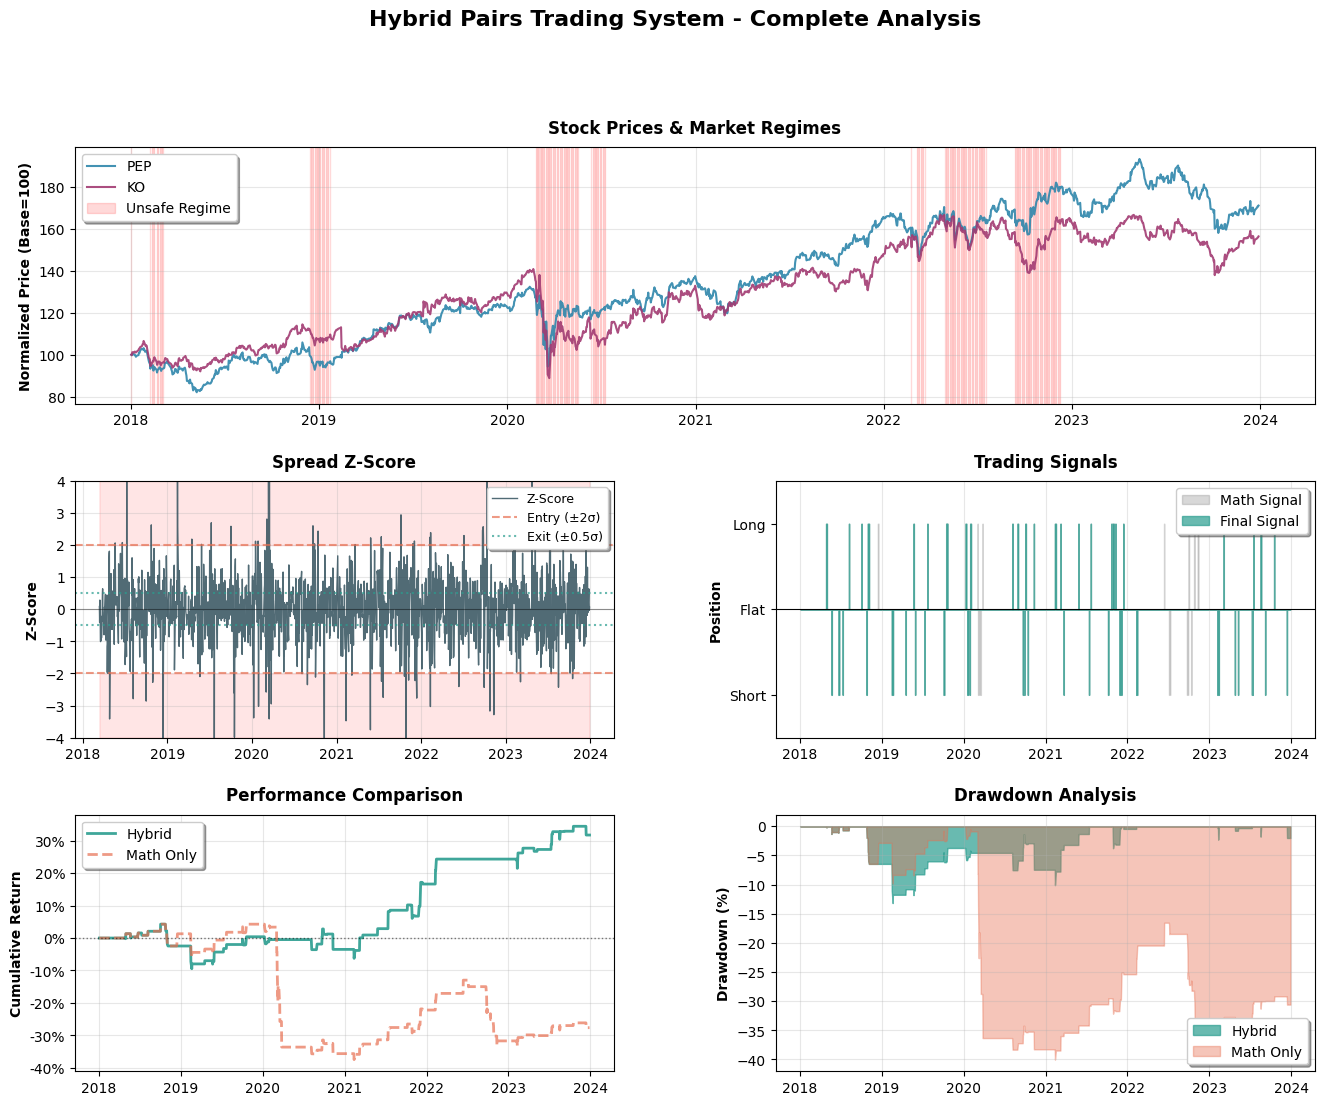


Creating regime analysis plot...


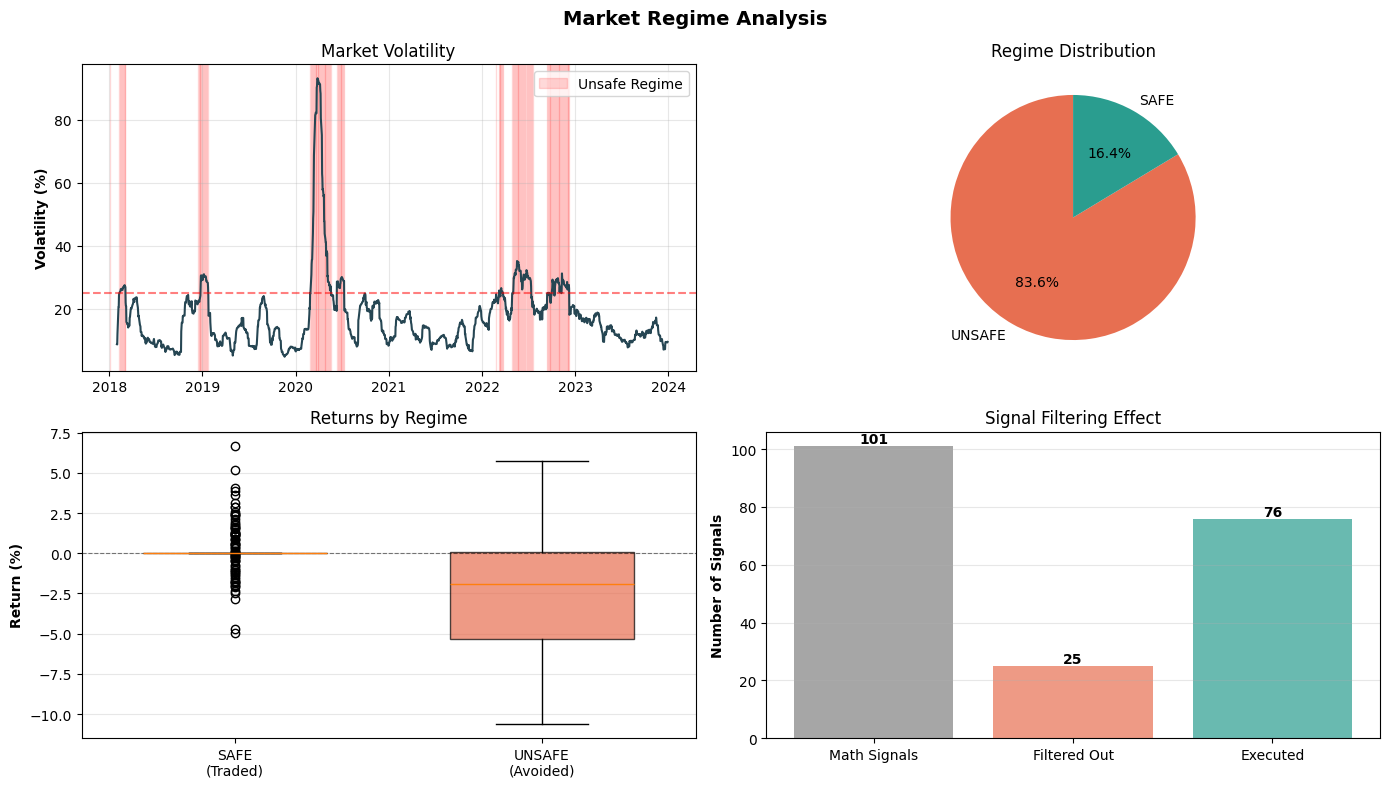


Creating interactive dashboard...


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [11]:

# ============================================================================
# MAIN ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    """
    Main entry point for the Hybrid Pairs Trading System.
    
    This demonstrates:
    1. Complete backtest workflow
    2. Performance analysis
    3. Visualization generation
    4. Multi-pair comparison (optional)
    """
    
    # Run example backtest
    system, results = run_example_backtest()
    
    # Optional: Compare multiple pairs
    # Uncomment the line below to run multi-pair comparison
    # compare_multiple_pairs()
    
    print("\n" + "="*80)
    print("SYSTEM COMPONENTS:")
    print("="*80)
    print("""
    1. MATHEMATICAL CORE (Kalman Filter):
       - Dynamically estimates hedge ratio between cointegrated stocks
       - Generates mean-reversion trading signals based on z-scores
       - Pure statistical arbitrage without machine learning
    
    2. MACHINE LEARNING (Random Forest Classifier):
       - Detects dangerous market regimes (high volatility, drawdowns)
       - Acts as a risk filter, NOT a signal generator
       - Protects the strategy during crisis periods
    
    3. HYBRID LOGIC:
       - Trade only when: (Math Signal) AND (Safe Regime)
       - Combines precision of math with adaptability of ML
       - Result: Higher Sharpe ratio, lower drawdown
    """)
    
    print("\n" + "="*80)
    print("TO USE THIS SYSTEM:")
    print("="*80)
    print("""
    # Basic usage:
    from hybrid_pairs_trading import *
    
    # Download your data
    stock_y, stock_x, market = download_data('TICKER1', 'TICKER2', 'SPY')
    
    # Initialize and run
    system = HybridPairsTradingSystem()
    results = system.run_backtest(stock_y, stock_x, market)
    
    # Analyze
    metrics = system.get_performance_metrics()
    trades = system.get_trade_analysis()
    
    # Visualize
    viz = TradingVisualizer(results, 'Stock1', 'Stock2')
    viz.plot_complete_analysis()
    viz.plot_regime_analysis()
    """)